In [5]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

class SimpleNeuralNetwork:
    def __init__(self):
        self.w1 = np.random.randn() * 0.5
        self.w2 = np.random.randn() * 0.5


        self.w3 = np.random.randn() * 0.5
        self.w4 = np.random.randn() * 0.5

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        self.z1 = self.w1 * X[0]
        self.z2 = self.w2 * X[1]
        self.a1 = self.z1
        self.a2 = self.z2

        self.z_out = self.w3 * self.a1 + self.w4 * self.a2
        self.y_pred = self.sigmoid(self.z_out).reshape(1, -1)

        return self.y_pred

    def compute_loss(self, y_true, y_pred):
        return np.sum((y_true - y_pred) ** 2)

    def backward(self, X, y_true):
        n = X.shape[1]

        dL_dy_pred = 2 * (self.y_pred - y_true)
        dy_pred_dz_out = self.y_pred * (1 - self.y_pred)

        dL_dz_out = (dL_dy_pred * dy_pred_dz_out).flatten()

        self.dw3 = np.sum(dL_dz_out * self.a1)
        self.dw4 = np.sum(dL_dz_out * self.a2)

        dL_da1 = dL_dz_out * self.w3
        dL_da2 = dL_dz_out * self.w4

        dL_dz1 = dL_da1
        dL_dz2 = dL_da2

        self.dw1 = np.sum(dL_dz1 * X[0])
        self.dw2 = np.sum(dL_dz2 * X[1])

    def update_weights(self, learning_rate):
        self.w1 -= learning_rate * self.dw1
        self.w2 -= learning_rate * self.dw2
        self.w3 -= learning_rate * self.dw3
        self.w4 -= learning_rate * self.dw4

    def train(self, X_train, y_train, epochs, learning_rate):
        losses = []

        for epoch in range(epochs):
            y_pred = self.forward(X_train)

            loss = self.compute_loss(y_train, y_pred) / X_train.shape[1]
            losses.append(loss)

            self.backward(X_train, y_train)

            self.update_weights(learning_rate)

            if (epoch + 1) % 10 == 0:
                print(f"Эпоха {epoch + 1}/{epochs}, Потери: {loss:.6f}")

        return losses

    def predict(self, X):
        return self.forward(X)

    def predict_class(self, X):
        y_pred = self.predict(X)
        return (y_pred >=  0.5).astype(int)

In [6]:
def generate_data(n_samples):
    X = np.random.uniform(-5, 5, (2, n_samples))
    y = (X[0] + X[1] > 0).astype(float).reshape(1, -1)
    return X, y


def evaluate_accuracy(model, X, y_true):
    y_pred_class = model.predict_class(X)[0]
    y_true_flat = y_true[0]

    TP = np.sum((y_pred_class == 1) & (y_true_flat == 1))  # True Positive
    TN = np.sum((y_pred_class == 0) & (y_true_flat == 0))  # True Negative
    FP = np.sum((y_pred_class == 1) & (y_true_flat == 0))  # False Positive
    FN = np.sum((y_pred_class == 0) & (y_true_flat == 1))  # False Negative

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    return accuracy

Эпоха 10/100, Потери: 0.087279
Эпоха 20/100, Потери: 0.108368
Эпоха 30/100, Потери: 0.006499
Эпоха 40/100, Потери: 0.107909
Эпоха 50/100, Потери: 0.091902
Эпоха 60/100, Потери: 0.046930
Эпоха 70/100, Потери: 0.012322
Эпоха 80/100, Потери: 0.013386
Эпоха 90/100, Потери: 0.006667
Эпоха 100/100, Потери: 0.051044

Обучающая выборка:
  Accuracy = 96.05%

Валидационная выборка:
  Accuracy = 99.00%


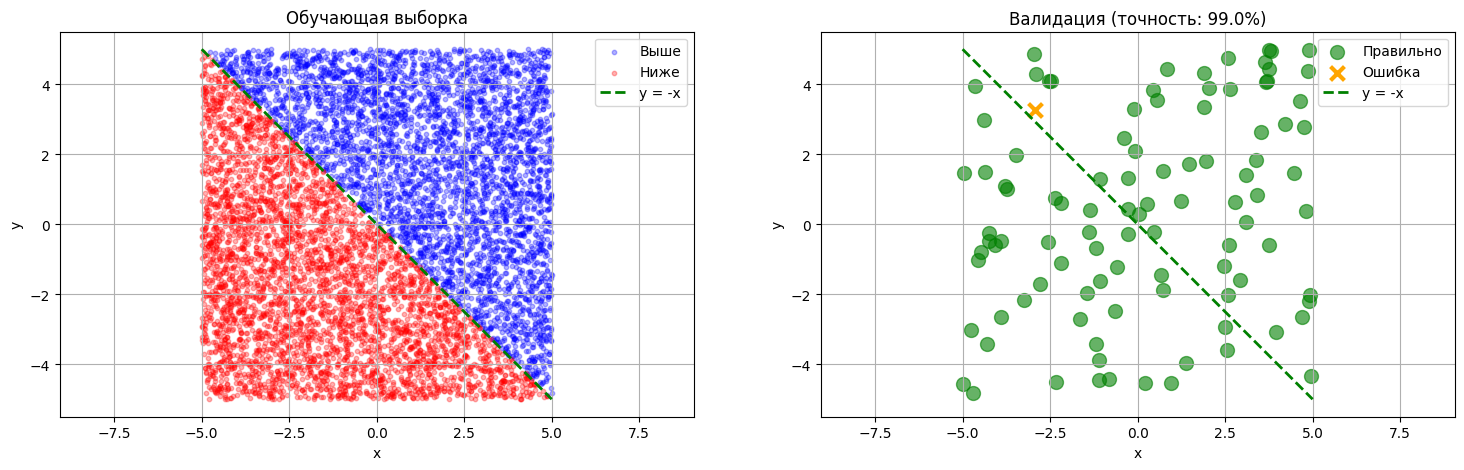

In [7]:
X_train, y_train = generate_data(8000)
X_val, y_val = generate_data(100)

model = SimpleNeuralNetwork()

learning_rate = 0.001
epochs = 100
losses = model.train(X_train, y_train, epochs=epochs, learning_rate=learning_rate)

train_accuracy = evaluate_accuracy(model, X_train, y_train)
print(f"\nОбучающая выборка:")
print(f"  Accuracy = {train_accuracy * 100:.2f}%")

val_accuracy = evaluate_accuracy(model, X_val, y_val)
print(f"\nВалидационная выборка:")
print(f"  Accuracy = {val_accuracy * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

x_coords_train = X_train[0]
y_coords_train = X_train[1]
mask_pos = (y_train[0] == 1)
mask_neg = ~mask_pos
colors_train = ['blue' if y == 1 else 'red' for y in y_train[0]]
axes[0].scatter(x_coords_train[mask_pos], y_coords_train[mask_pos], c='blue', alpha=0.3, s=10, label='Выше')
axes[0].scatter(x_coords_train[mask_neg], y_coords_train[mask_neg], c='red',  alpha=0.3, s=10, label='Ниже')
x_line = np.linspace(-5, 5, 100)
axes[0].plot(x_line, -x_line, 'g--', linewidth=2, label='y = -x')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Обучающая выборка')
axes[0].legend()
axes[0].grid(True)
axes[0].axis('equal')

x_coords_val = X_val[0]
y_coords_val = X_val[1]
y_pred_val = model.predict_class(X_val)[0]
y_true_val = y_val[0]

correct_mask = (y_pred_val == y_true_val)
incorrect_mask = ~correct_mask

axes[1].scatter(x_coords_val[correct_mask], y_coords_val[correct_mask], c='green', marker='o', s=100, alpha=0.6, label='Правильно')
axes[1].scatter(x_coords_val[incorrect_mask], y_coords_val[incorrect_mask], c='orange', marker='x', s=100, linewidths=3, label='Ошибка')
axes[1].plot(x_line, -x_line, 'g--', linewidth=2, label='y = -x')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(f'Валидация (точность: {val_accuracy*100:.1f}%)')
axes[1].legend()
axes[1].grid(True)
axes[1].axis('equal')


plt.show()

In [8]:
lambda_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
results = []

for lr in lambda_values:
    print(f"\nОбучение с lambda = {lr} ")

    test_model = SimpleNeuralNetwork()
    test_model.train(X_train, y_train, epochs=epochs, learning_rate=lr)

    train_acc = evaluate_accuracy(test_model, X_train, y_train)
    val_acc= evaluate_accuracy(test_model, X_val, y_val)

    y_pred_final = test_model.predict(X_train)
    final_loss = test_model.compute_loss(y_train, y_pred_final) / X_train.shape[1]

    print(f"Train Acc: {train_acc*100:.2f}%, Val Acc: {val_acc*100:.2f}%, Final loss: {final_loss:.2f}")


Обучение с lambda = 0.001 
Эпоха 10/100, Потери: 0.068629
Эпоха 20/100, Потери: 0.008322
Эпоха 30/100, Потери: 0.118309
Эпоха 40/100, Потери: 0.106317
Эпоха 50/100, Потери: 0.078669
Эпоха 60/100, Потери: 0.074836
Эпоха 70/100, Потери: 0.078183
Эпоха 80/100, Потери: 0.013800
Эпоха 90/100, Потери: 0.005612
Эпоха 100/100, Потери: 0.012797
Train Acc: 91.88%, Val Acc: 96.00%, Final loss: 0.08

Обучение с lambda = 0.005 
Эпоха 10/100, Потери: 0.068926
Эпоха 20/100, Потери: 0.027586
Эпоха 30/100, Потери: 0.005108
Эпоха 40/100, Потери: 0.099070
Эпоха 50/100, Потери: 0.063680
Эпоха 60/100, Потери: 0.078568
Эпоха 70/100, Потери: 0.071762
Эпоха 80/100, Потери: 0.014751
Эпоха 90/100, Потери: 0.021015
Эпоха 100/100, Потери: 0.089042
Train Acc: 94.55%, Val Acc: 97.00%, Final loss: 0.05

Обучение с lambda = 0.01 
Эпоха 10/100, Потери: 0.754162
Эпоха 20/100, Потери: 0.752514
Эпоха 30/100, Потери: 0.746199
Эпоха 40/100, Потери: 0.739750
Эпоха 50/100, Потери: 0.726122
Эпоха 60/100, Потери: 0.643607
Эпо